In [1]:
#install.packages("AER")
library(AER)

Installing package into 'C:/Users/jet_v/AppData/Local/R/win-library/4.4'
(as 'lib' is unspecified)



package 'AER' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\jet_v\AppData\Local\Temp\RtmpETtfHj\downloaded_packages


Loading required package: car

Loading required package: carData

Loading required package: lmtest

Loading required package: zoo


Attaching package: 'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric


Loading required package: sandwich

Loading required package: survival



'data.frame':	2220 obs. of  7 variables:
 $ id      : int  3 4 5 6 7 8 9 10 11 12 ...
 $ wage    : int  481 721 250 729 500 565 608 425 515 225 ...
 $ educ    : int  12 12 11 12 12 18 14 12 12 9 ...
 $ exper   : int  9 16 10 16 8 9 9 10 11 13 ...
 $ nearc4  : int  0 0 1 1 1 1 1 1 1 1 ...
 $ fatheduc: int  8 14 11 8 9 14 14 12 12 11 ...
 $ motheduc: int  8 12 12 7 12 14 14 12 12 12 ...


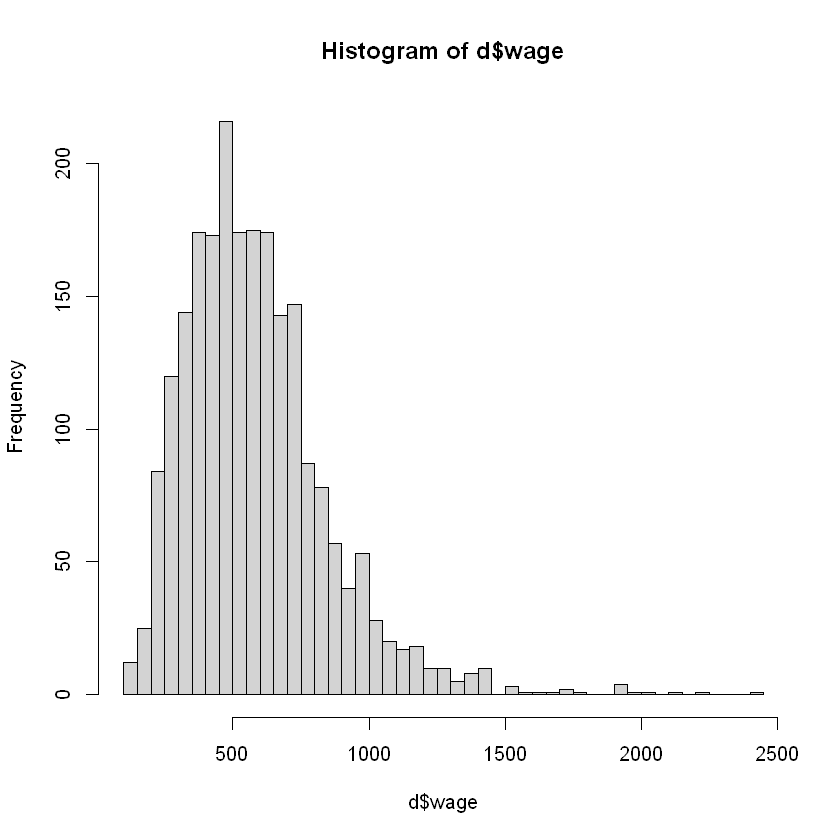

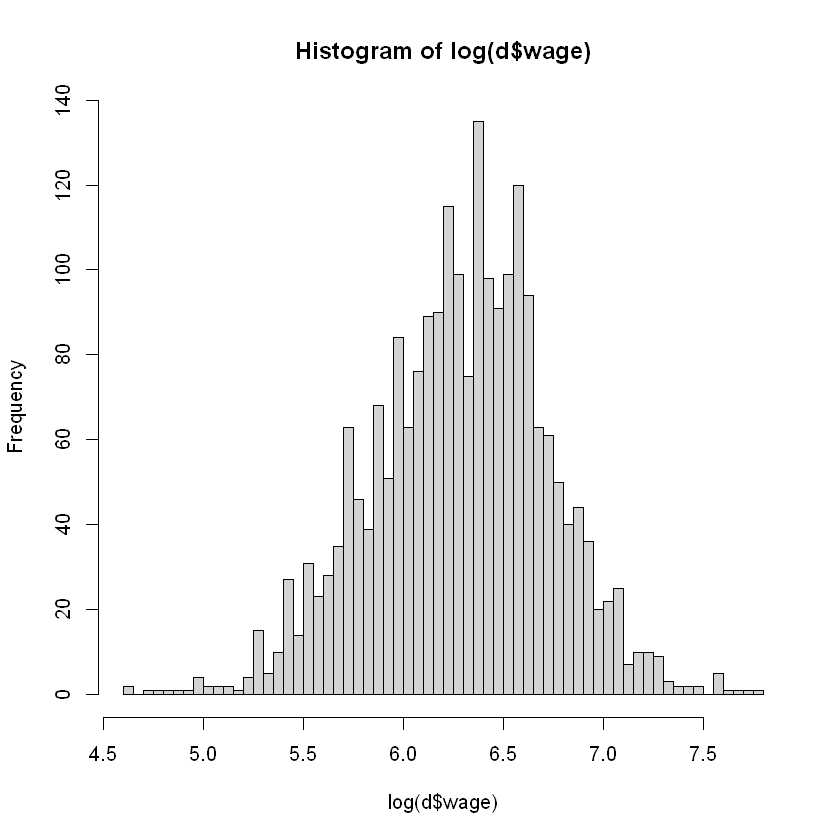

In [7]:
d <- read.csv("Education_data.csv", header = TRUE)
str(d)
hist(d$wage, breaks = 40)
hist(log(d$wage), breaks = 50)

In [8]:
ols.res <- lm(log(wage)~educ+exper+I(exper^2), data = d)
summary(ols.res)


Call:
lm(formula = log(wage) ~ educ + exper + I(exper^2), data = d)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.95790 -0.25052  0.02293  0.26081  1.46722 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  4.5058302  0.0796664  56.559  < 2e-16 ***
educ         0.0897809  0.0041614  21.575  < 2e-16 ***
exper        0.0932152  0.0083042  11.225  < 2e-16 ***
I(exper^2)  -0.0025751  0.0004171  -6.174  7.9e-10 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.3964 on 2216 degrees of freedom
Multiple R-squared:  0.1884,	Adjusted R-squared:  0.1873 
F-statistic: 171.5 on 3 and 2216 DF,  p-value: < 2.2e-16


In [12]:
s1 <- lm(educ~nearc4+exper+I(exper^2), data = d)
summary(s1)


Call:
lm(formula = educ ~ nearc4 + exper + I(exper^2), data = d)

Residuals:
    Min      1Q  Median      3Q     Max 
-7.5848 -1.4656 -0.0982  1.3445  5.4292 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 16.777824   0.192250  87.271  < 2e-16 ***
nearc4       0.488194   0.092376   5.285 1.38e-07 ***
exper       -0.436376   0.041112 -10.614  < 2e-16 ***
I(exper^2)   0.001567   0.002116   0.741    0.459    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 2.011 on 2216 degrees of freedom
Multiple R-squared:  0.397,	Adjusted R-squared:  0.3962 
F-statistic: 486.3 on 3 and 2216 DF,  p-value: < 2.2e-16


In [13]:
s2 <- lm(log(wage)~fitted(s1)+exper+I(exper^2), data = d)
summary(s2)


Call:
lm(formula = log(wage) ~ fitted(s1) + exper + I(exper^2), data = d)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.77434 -0.26580  0.02892  0.28324  1.44498 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  1.5510697  0.6972775   2.224   0.0262 *  
fitted(s1)   0.2623096  0.0406510   6.453 1.35e-10 ***
exper        0.1683191  0.0197776   8.511  < 2e-16 ***
I(exper^2)  -0.0028025  0.0004577  -6.123 1.08e-09 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.432 on 2216 degrees of freedom
Multiple R-squared:  0.03605,	Adjusted R-squared:  0.03475 
F-statistic: 27.63 on 3 and 2216 DF,  p-value: < 2.2e-16


In [14]:
TSLS.res <- ivreg(log(wage)~educ+exper+I(exper^2)|nearc4+exper+I(exper^2), data = d)
summary(TSLS.res)


Call:
ivreg(formula = log(wage) ~ educ + exper + I(exper^2) | nearc4 + 
    exper + I(exper^2), data = d)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.42541 -0.34345  0.01868  0.34863  2.05463 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  1.5510697  0.8525622   1.819    0.069 .  
educ         0.2623096  0.0497041   5.277 1.44e-07 ***
exper        0.1683191  0.0241821   6.960 4.45e-12 ***
I(exper^2)  -0.0028025  0.0005596  -5.008 5.93e-07 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.5282 on 2216 degrees of freedom
Multiple R-Squared: -0.4411,	Adjusted R-squared: -0.4431 
Wald test: 18.48 on 3 and 2216 DF,  p-value: 7.691e-12 


In [15]:
cbind(coef(ols.res), coef(TSLS.res))

(Intercept),4.505830153,1.551069675
educ,0.089780913,0.262309622
exper,0.093215202,0.168319115
I(exper^2),-0.002575052,-0.002802532
